# Pré-processamento das transcrições

* **Armazenando textos no data_frame** 


In [1]:
import os
import pandas as pd

transcriptions_folder = '../transcriptions'

data = []

for file in os.listdir(transcriptions_folder): # retorna uma lista com os nomes de tudo que esta dentro de transcriptions_folder
    if os.path.isfile(os.path.join(transcriptions_folder,file)): # verifica se o caminho aponta para um arquivo existente
        file_path = os.path.join(transcriptions_folder,file) # caminho de cada file
        try:
            with open(file_path,'r') as f:
                text = f.read()
                id = file.replace('.txt','')
                data.append({'id': id, 'text': text}) # guarda o id do vídeo e a transcrição nele presente
        except Exception as e:
            print(f"Erro ao ler o arquivo {file}: {e}")

df = pd.DataFrame(data)
display(df)


,id,text
0,P4VjVG3lt1E,e aí e bora aí galera fiz um vídeozinho peque...
1,cfDBwrkINHo,Fala rapaziada mano pega a visão vem aqui pra...
2,URw3_PM_mhs,"Olá a todos, fala que Marcelo Lisboa sejam be..."
3,Tn6X9lKvM9Q,tal rapaziada beleza que quem fala que vocês ...
4,C3pjP175-Uk,fala minha tropinha e como é que vocês estão ...
...,...,...
1952,WJNbIUAmbMU,"Fala galera, passando no início aqui do vídeo..."
1953,80r3-jnvywA,"Eu sou eu, sou eu Eu via no rádio de pilha um..."
1954,bpKtV5F96fc,"Fala galera, tudo bom com vocês? Como vocês e..."
1955,YJZbmcaShFU,Fizemos a parte de um dos mais importantes. A...


,id,text,Word_count
0,P4VjVG3lt1E,e aí e bora aí galera fiz um vídeozinho peque...,147
1,cfDBwrkINHo,Fala rapaziada mano pega a visão vem aqui pra...,1545
2,URw3_PM_mhs,"Olá a todos, fala que Marcelo Lisboa sejam be...",2517
3,Tn6X9lKvM9Q,tal rapaziada beleza que quem fala que vocês ...,526
4,C3pjP175-Uk,fala minha tropinha e como é que vocês estão ...,1445
...,...,...,...
1952,WJNbIUAmbMU,"Fala galera, passando no início aqui do vídeo...",652
1953,80r3-jnvywA,"Eu sou eu, sou eu Eu via no rádio de pilha um...",24
1954,bpKtV5F96fc,"Fala galera, tudo bom com vocês? Como vocês e...",862
1955,YJZbmcaShFU,Fizemos a parte de um dos mais importantes. A...,204


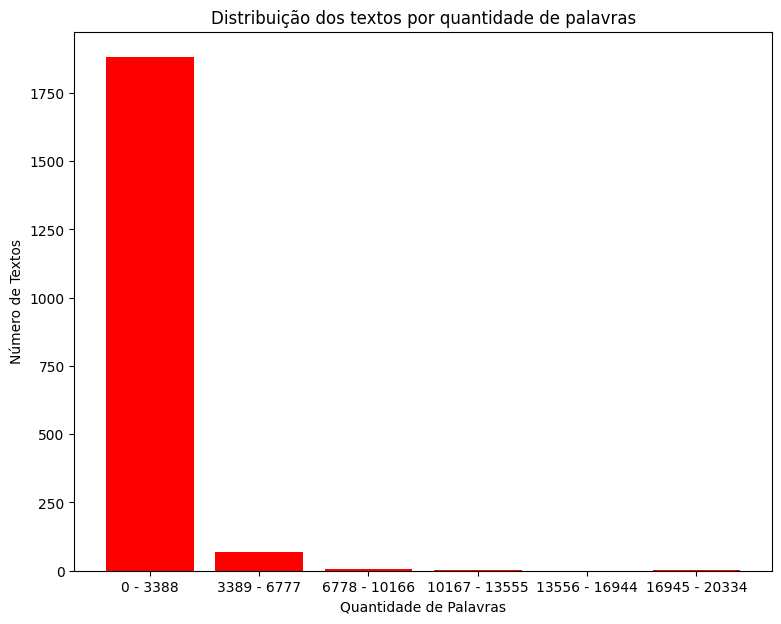

In [2]:
import matplotlib.pyplot as plt
import numpy as np

df["Word_count"] = df["text"].apply(lambda x: len(x.split())) # Número de palavras por documento
# Split divide o texto em palavras usando espaço como separador
display(df)

max_words = df['Word_count'].max()
num_bar = 6 #Quantas barras terá o gráfico

labels = []
bin_range = int(max_words/num_bar) #o tamanho do intervalo de cada barra
bins = [i * bin_range for i in range(num_bar)]
bins.append(max_words + 1)

for i in range(num_bar):
    lower_bound = bins[i] #o início de cada intervalo
    upper_bound = (bins[i+1] - 1) if i<(num_bar-1) else max_words #o fim de cada intervalo
    labels.append(f"{lower_bound} - {upper_bound}") #o início-fim de cada barra, baseado no tamanho dos intervalos

bin_word = pd.cut(df["Word_count"], bins=bins, labels=labels, right=False, include_lowest=True) #de qual intervalo cada texto faz parte
counts_bin = bin_word.value_counts().sort_index()

plt.figure(figsize=(9, 7))
plt.bar(labels, counts_bin, color="red")
plt.xlabel('Quantidade de Palavras')
plt.ylabel('Número de Textos')
plt.title('Distribuição dos textos por quantidade de palavras')
plt.show()

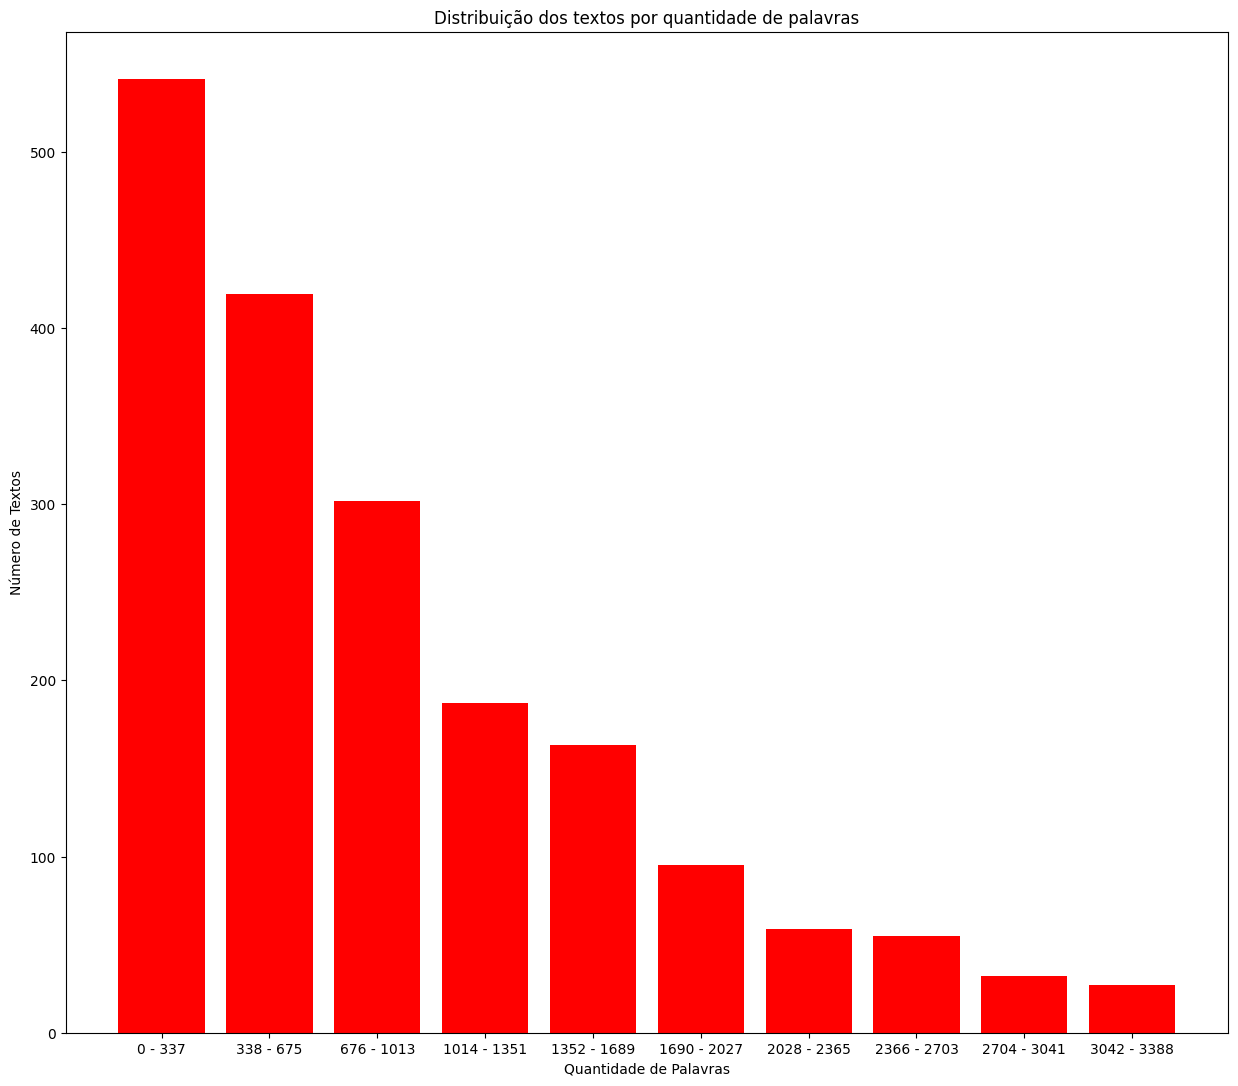

In [3]:
df["Word_count"] = df["text"].apply(lambda x: len(x.split())) # Número de palavras por documento
# Split divide o texto em palavras usando espaço como separador

max_words = 3388
num_bar = 10 #Quantas barras terá o gráfico

labels = []
bin_range = int(max_words/num_bar) #o tamanho do intervalo de cada barra
bins = [i * bin_range for i in range(num_bar)]
bins.append(max_words + 1)

for i in range(num_bar):
    lower_bound = bins[i] #o início de cada intervalo
    upper_bound = (bins[i+1] - 1) if i<(num_bar-1) else max_words #o fim de cada intervalo
    labels.append(f"{lower_bound} - {upper_bound}") #o início-fim de cada barra, baseado no tamanho dos intervalos

bin_word = pd.cut(df["Word_count"], bins=bins, labels=labels, right=False, include_lowest=True) #de qual intervalo cada texto faz parte
counts_bin = bin_word.value_counts().sort_index()

plt.figure(figsize=(15, 13))
plt.bar(labels, counts_bin, color="red")
plt.xlabel('Quantidade de Palavras')
plt.ylabel('Número de Textos')
plt.title('Distribuição dos textos por quantidade de palavras')
plt.show()

In [4]:
df["Word_count"].describe() #Alguns dados
# Count: número de mensagens
# Mean: média de palavras por mensagem
# Std: desvio padrão (o quanto as mensagens variam em relação à média)
# Min: a menor mensagem tem nenhuma palavra
# 25%: 25% das mensagens têm até 253 palavras
# Max: a maior mensagem tem 20334 palavras

count     1957.000000
mean      1011.184466
std       1160.927001
min          0.000000
25%        253.000000
50%        690.000000
75%       1395.000000
max      20334.000000
Name: Word_count, dtype: float64

In [5]:
# Transcrições com zero palavras

# Filtra transcrições com zero palavras
transcricoes_vazias = df[df['Word_count'] == 0]

# Conta quantas são
print(f"Transcrições com zero palavras: {len(transcricoes_vazias)}")

# Mostra os IDs dos vídeos com transcrição vazia
print("IDs dos vídeos com transcrição vazia:")
print(transcricoes_vazias['id'].tolist())

Transcrições com zero palavras: 23
IDs dos vídeos com transcrição vazia:
['SKzCWxjxqk4', 'moee64Anbx4', 'oqPVyKQpjfw', 'GPaVW3dN3Ws', 'kY6BEMVrFL4', 'aOAgOqnctRo', 'Lzxu3g3ZZFw', '3U21ob1pCL4', 'Z5mgD_xDAfU', '4WI3UzU6eQQ', 'Bsx6d-_dlJ4', 'U8D9CWMYtJ0', 'TCu-mfyAHm0', 'NjHj4n3ovtY', 'VDaD2RgFJAA', 'LookslPMQ4U', '7B8YXbGxc1o', 'Sz_nOI_Dn74', 'v7VBGT7pzKM', 'PIubLzB5AKs', 'eW3EPPLRqY0', 'h7Tu2FMtm1Q', 'JZEhJCt7NBo']


In [6]:
# Conta quantas palavras diferentes tem em cada documento (vocabulário)

def count_unique_words(text):
    words = text.lower().split() # Converte para minúsculas
    unique_words = set(words) # Use a set to get only unique words
    return len(unique_words) # Return the count of unique words

df["Unique_Word_count"] = df["text"].apply(count_unique_words) # Nova coluna para a contagem de palavras diferentes

# Display the DataFrame with the new column
display(df)


,id,text,Word_count,Unique_Word_count
0,P4VjVG3lt1E,e aí e bora aí galera fiz um vídeozinho peque...,147,87
1,cfDBwrkINHo,Fala rapaziada mano pega a visão vem aqui pra...,1545,390
2,URw3_PM_mhs,"Olá a todos, fala que Marcelo Lisboa sejam be...",2517,713
3,Tn6X9lKvM9Q,tal rapaziada beleza que quem fala que vocês ...,526,225
4,C3pjP175-Uk,fala minha tropinha e como é que vocês estão ...,1445,322
...,...,...,...,...
1952,WJNbIUAmbMU,"Fala galera, passando no início aqui do vídeo...",652,309
1953,80r3-jnvywA,"Eu sou eu, sou eu Eu via no rádio de pilha um...",24,21
1954,bpKtV5F96fc,"Fala galera, tudo bom com vocês? Como vocês e...",862,286
1955,YJZbmcaShFU,Fizemos a parte de um dos mais importantes. A...,204,8


In [7]:
df["Unique_Word_count"].describe() #Alguns dados
# Count: número de mensagens
# Mean: média de palavras por mensagem
# Std: desvio padrão (o quanto as mensagens variam em relação à média)
# Min: a menor mensagem tem nenhuma palavra
# 25%: 25% das mensagens têm até 253 palavras
# Max: a maior mensagem tem 20334 palavras

count    1957.000000
mean      312.307103
std       278.017695
min         0.000000
25%        97.000000
50%       272.000000
75%       429.000000
max      4329.000000
Name: Unique_Word_count, dtype: float64

* **Pré processamento**

In [8]:
from PreProcessing import PreProcessing

def preprocessing(df):
    pp = PreProcessing(language="pt")

    #1: Deixar tudo em minúsuculo e remover acentos
    df["text"] = pp.lowercase_unidecode(df["text"])

    #2: Remover URLs
    df["text"] = pp.remove_urls(df["text"])

    #3: Remover mercações
    df["text"] = pp.remove_tweet_marking(df["text"])

    #4: Remover links
    df["text"] = pp.remove_html_tags(df["text"])

    return df

df_clean = preprocessing(df)
display(df_clean)


,id,text,Word_count,Unique_Word_count
0,P4VjVG3lt1E,e ai e bora ai galera fiz um videozinho pequen...,147,87
1,cfDBwrkINHo,fala rapaziada mano pega a visao vem aqui pra ...,1545,390
2,URw3_PM_mhs,"ola a todos, fala que marcelo lisboa sejam bem...",2517,713
3,Tn6X9lKvM9Q,tal rapaziada beleza que quem fala que voces e...,526,225
4,C3pjP175-Uk,fala minha tropinha e como e que voces estao t...,1445,322
...,...,...,...,...
1952,WJNbIUAmbMU,"fala galera, passando no inicio aqui do video ...",652,309
1953,80r3-jnvywA,"eu sou eu, sou eu eu via no radio de pilha um ...",24,21
1954,bpKtV5F96fc,"fala galera, tudo bom com voces? como voces es...",862,286
1955,YJZbmcaShFU,fizemos a parte de um dos mais importantes. a ...,204,8


In [9]:
def pegar_texto_por_id(dataframe: pd.DataFrame, id: str):
    # Encontra a linha com o ID desejado
    resultado = dataframe[dataframe['id'] == id]

    # Verifica se o ID foi encontrado
    if not resultado.empty:
        # Se encontrado, imprime o texto da primeira ocorrência
        # .iloc[0] para pegar a primeira linha do resultado filtrado
        # ['text'] para acessar a coluna 'text'
        print(f"Texto - ID '{id}':")
        print(resultado.iloc[0]['text'])
    else:
        print(f"ID '{id}' não encontrado.")

ids = ['0fXeUDlMh58', '0JH-peGeAzE', '3ERF3oXUjCM', '34JrpfyF0rU', 'OlqOKw4FZOA', '80r3-jnvywA', 'bGD5J3O5qtA', '_mryDWPz1tM', '2D6NUBHDyzo']

for id_atual in ids:
    pegar_texto_por_id(df, id_atual)
    print("-" * 130)

Texto - ID '0fXeUDlMh58':
o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que e o que 

In [10]:
AUDIOS_RUINS = "../filtrated_data_log/ids_audios_ruins.csv"
ids_audios_ruins = pd.read_csv(AUDIOS_RUINS)
print(ids_audios_ruins)

        ID_Audio
0    hEPS5wpurkM
1    t0OEDe-h7Ew
2    RTekEjC4Nps
3    GC2LRe0U5E8
4    tMXTbckeQ-0
..           ...
840  bDGBT2VKXx0
841  Gvxm13mK5u8
842  dX4rqi4_iss
843  kN3p6HIfW3Y
844  zfKxM-uFgho

[845 rows x 1 columns]


In [11]:
filtro_ids = df['id'].isin(ids_audios_ruins['ID_Audio'])
df_audios_ruins = df[filtro_ids].copy()
display(df_audios_ruins)

filtro_ids_bons = ~filtro_ids
df_audios_bons = df[filtro_ids_bons].copy()
display(df_audios_bons)

,id,text,Word_count,Unique_Word_count
8,oUYku2T9pDQ,"muito bom, yuggaji! dizem queunaiuda!sim... vo...",26,25
12,dNSxsxnRqKI,"salve galera, gia ganarinha trazendo mais vide...",2190,540
14,WQjNB0S0zOs,"meu telefone tem nem um aplicativo de jogo, ne...",190,109
16,2jA-wDu8m5Y,a casa caio foi realizada uma operacao em sao ...,1866,684
20,fVBIzB1zSf8,fala rapaziada mano pega a visao vem aqui pra ...,2279,532
...,...,...,...,...
1949,OYDxnT7FoT0,oi gente tudo bem sula aqui trazendo pra voces...,305,141
1950,pVO5-BA9IYo,"e vemo um doenho ai, beleza? de 100 reais eita...",533,227
1953,80r3-jnvywA,"eu sou eu, sou eu eu via no radio de pilha um ...",24,21
1955,YJZbmcaShFU,fizemos a parte de um dos mais importantes. a ...,204,8


,id,text,Word_count,Unique_Word_count
0,P4VjVG3lt1E,e ai e bora ai galera fiz um videozinho pequen...,147,87
1,cfDBwrkINHo,fala rapaziada mano pega a visao vem aqui pra ...,1545,390
2,URw3_PM_mhs,"ola a todos, fala que marcelo lisboa sejam bem...",2517,713
3,Tn6X9lKvM9Q,tal rapaziada beleza que quem fala que voces e...,526,225
4,C3pjP175-Uk,fala minha tropinha e como e que voces estao t...,1445,322
...,...,...,...,...
1947,rdnlzMrpuMA,"o video ja comeca daquele jeito, eu acabei de ...",572,234
1948,dNp1axRNEls,"jogo do tigrinho, voce ja ouviu, voce ja jogou...",828,370
1951,mOKM_W4sHzY,salve salve meu rapazera beleza? sejam bem vin...,1909,555
1952,WJNbIUAmbMU,"fala galera, passando no inicio aqui do video ...",652,309


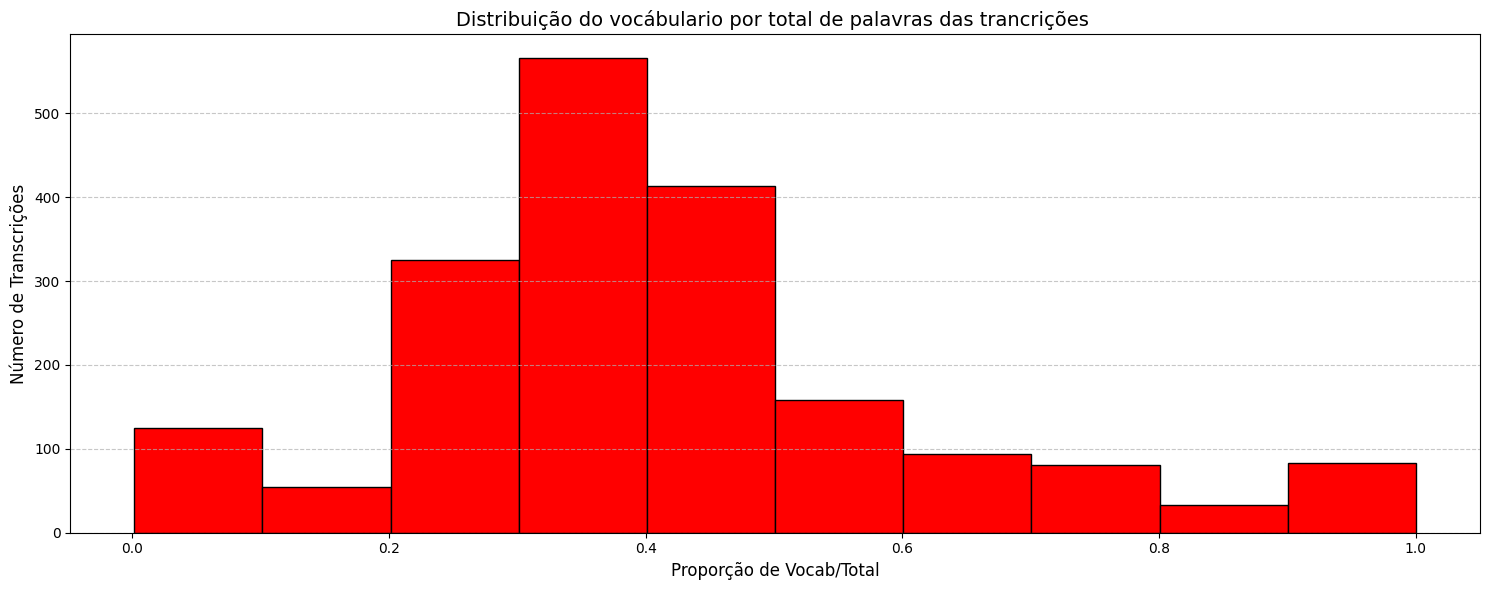

In [12]:
df['Unique_Word_count/Word_count'] = df['Unique_Word_count'] / df['Word_count']

plt.figure(figsize=(15, 6))
n, bins_edges, patches = plt.hist(df['Unique_Word_count/Word_count'], bins=10, color='red', edgecolor='black')

plt.xlabel('Proporção de Vocab/Total', fontsize=12)
plt.ylabel('Número de Transcrições', fontsize=12)
plt.title('Distribuição do vocábulario por total de palavras das trancrições ', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

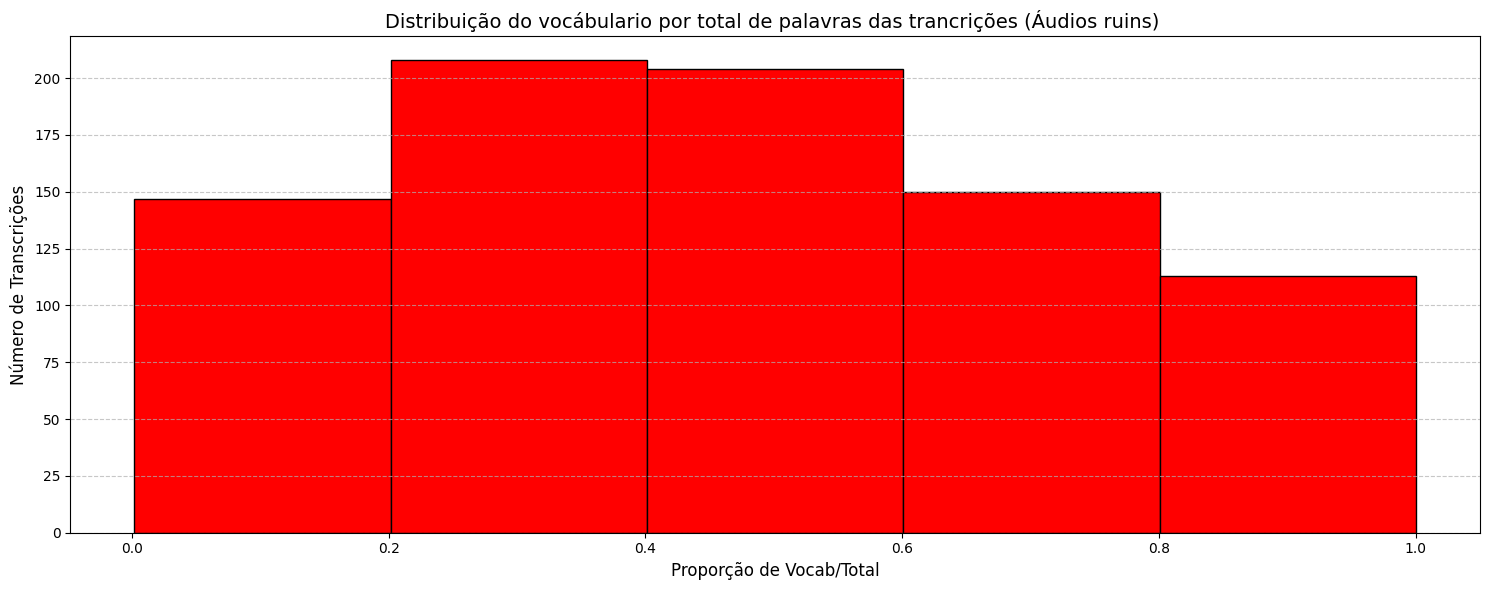

In [13]:
df_audios_ruins['Unique_Word_count/Word_count'] = df_audios_ruins['Unique_Word_count'] / df_audios_ruins['Word_count']

plt.figure(figsize=(15, 6))
n, bins_edges, patches = plt.hist(df_audios_ruins['Unique_Word_count/Word_count'], bins=5, color='red', edgecolor='black')

plt.xlabel('Proporção de Vocab/Total', fontsize=12)
plt.ylabel('Número de Transcrições', fontsize=12)
plt.title('Distribuição do vocábulario por total de palavras das trancrições (Áudios ruins) ', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

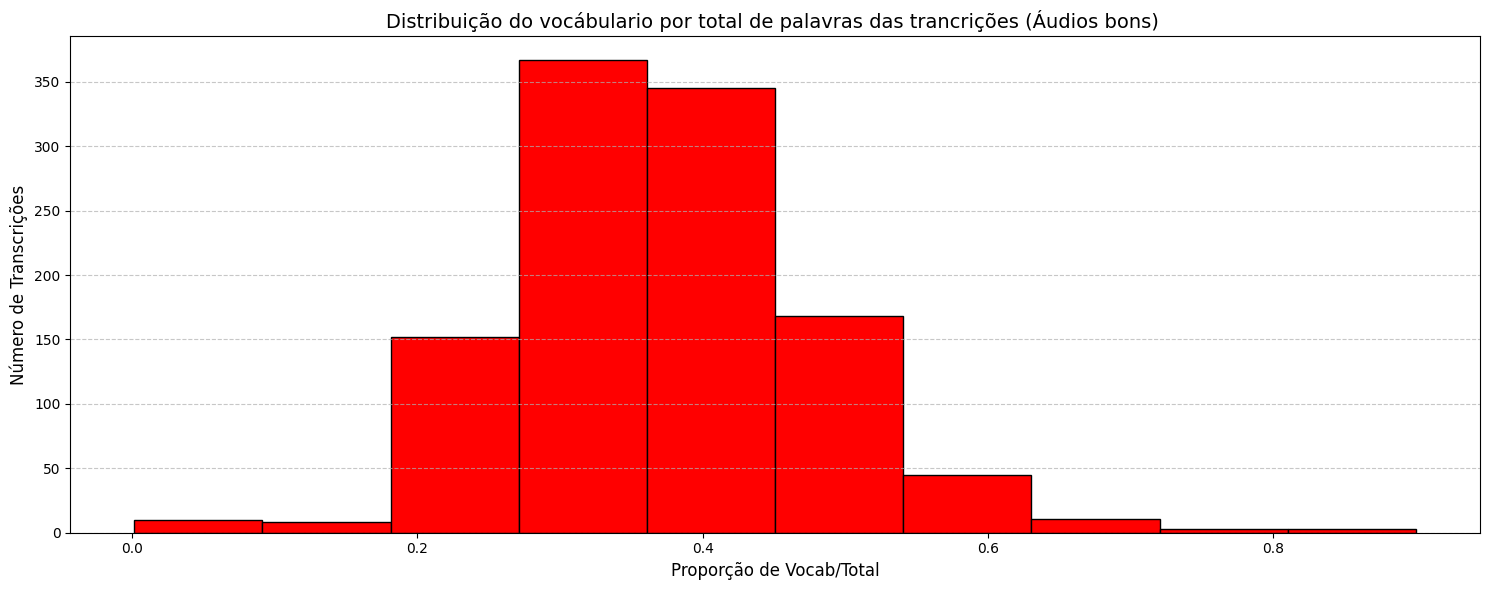

In [14]:
df_audios_bons['Unique_Word_count/Word_count'] = df_audios_bons['Unique_Word_count'] / df_audios_bons['Word_count']

plt.figure(figsize=(15, 6))
n, bins_edges, patches = plt.hist(df_audios_bons['Unique_Word_count/Word_count'], bins=10, color='red', edgecolor='black')

plt.xlabel('Proporção de Vocab/Total', fontsize=12)
plt.ylabel('Número de Transcrições', fontsize=12)
plt.title('Distribuição do vocábulario por total de palavras das trancrições (Áudios bons) ', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
df_audios_sil_temp = pd.read_csv("../filtrated_data_log/ids_audios_sil_temp.csv")
display(df_audios_sil_temp)

,arquivo,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,duracao_categoria,silencio/tempo
0,hEPS5wpurkM.mp3,66.850249,44100,0.104044,0.962973,0.108045,136.467381,0.061401,0,>60s,0.000000
1,XXBh0Fydirk.mp3,634.775521,48000,0.058259,1.093412,0.053282,21.353328,0.058474,25,>60s,0.039384
2,3IloQUdQ6T8.mp3,613.343500,48000,0.087393,1.104916,0.079095,23.552988,0.036577,15,>60s,0.024456
3,t0OEDe-h7Ew.mp3,866.127542,48000,0.066992,1.013549,0.066096,27.605300,0.062524,1,>60s,0.001155
4,RTekEjC4Nps.mp3,22.101333,48000,0.225782,1.193549,0.189169,31.268148,0.056754,0,10-25s,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
885,bDGBT2VKXx0.mp3,135.808000,48000,0.014452,0.229142,0.063070,23.983972,0.043809,0,>60s,0.000000
886,Gvxm13mK5u8.mp3,69.450896,48000,0.073567,0.980765,0.075010,36.162817,0.034724,1,>60s,0.014399
887,dX4rqi4_iss.mp3,14.464000,48000,0.188685,1.164248,0.162066,60.525055,0.076055,0,10-25s,0.000000
888,kN3p6HIfW3Y.mp3,75.209438,48000,0.137584,1.105482,0.124456,66.339850,0.043569,0,>60s,0.000000


In [16]:
df_audios_sil_temp['arquivo'] = [arquivo.replace('.mp3','') for arquivo in df_audios_sil_temp['arquivo'] ]
df_audios_sil_temp = df_audios_sil_temp.rename(columns={'arquivo':'id'})
display(df_audios_sil_temp)


,id,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,duracao_categoria,silencio/tempo
0,hEPS5wpurkM,66.850249,44100,0.104044,0.962973,0.108045,136.467381,0.061401,0,>60s,0.000000
1,XXBh0Fydirk,634.775521,48000,0.058259,1.093412,0.053282,21.353328,0.058474,25,>60s,0.039384
2,3IloQUdQ6T8,613.343500,48000,0.087393,1.104916,0.079095,23.552988,0.036577,15,>60s,0.024456
3,t0OEDe-h7Ew,866.127542,48000,0.066992,1.013549,0.066096,27.605300,0.062524,1,>60s,0.001155
4,RTekEjC4Nps,22.101333,48000,0.225782,1.193549,0.189169,31.268148,0.056754,0,10-25s,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
885,bDGBT2VKXx0,135.808000,48000,0.014452,0.229142,0.063070,23.983972,0.043809,0,>60s,0.000000
886,Gvxm13mK5u8,69.450896,48000,0.073567,0.980765,0.075010,36.162817,0.034724,1,>60s,0.014399
887,dX4rqi4_iss,14.464000,48000,0.188685,1.164248,0.162066,60.525055,0.076055,0,10-25s,0.000000
888,kN3p6HIfW3Y,75.209438,48000,0.137584,1.105482,0.124456,66.339850,0.043569,0,>60s,0.000000


In [20]:
filtro_ids = df['id'].isin(df_audios_sil_temp['id'])
df_vocab_sil = df[filtro_ids].copy()
display(df_vocab_sil)


,id,text,Word_count,Unique_Word_count,Unique_Word_count/Word_count
8,oUYku2T9pDQ,"muito bom, yuggaji! dizem queunaiuda!sim... vo...",26,25,0.961538
12,dNSxsxnRqKI,"salve galera, gia ganarinha trazendo mais vide...",2190,540,0.246575
16,2jA-wDu8m5Y,a casa caio foi realizada uma operacao em sao ...,1866,684,0.366559
20,fVBIzB1zSf8,fala rapaziada mano pega a visao vem aqui pra ...,2279,532,0.233436
22,d5jHul9ecNY,"e o joguinho do tigre, hein galera? eu sabia q...",194,127,0.654639
...,...,...,...,...,...
1949,OYDxnT7FoT0,oi gente tudo bem sula aqui trazendo pra voces...,305,141,0.462295
1950,pVO5-BA9IYo,"e vemo um doenho ai, beleza? de 100 reais eita...",533,227,0.425891
1953,80r3-jnvywA,"eu sou eu, sou eu eu via no radio de pilha um ...",24,21,0.875000
1955,YJZbmcaShFU,fizemos a parte de um dos mais importantes. a ...,204,8,0.039216


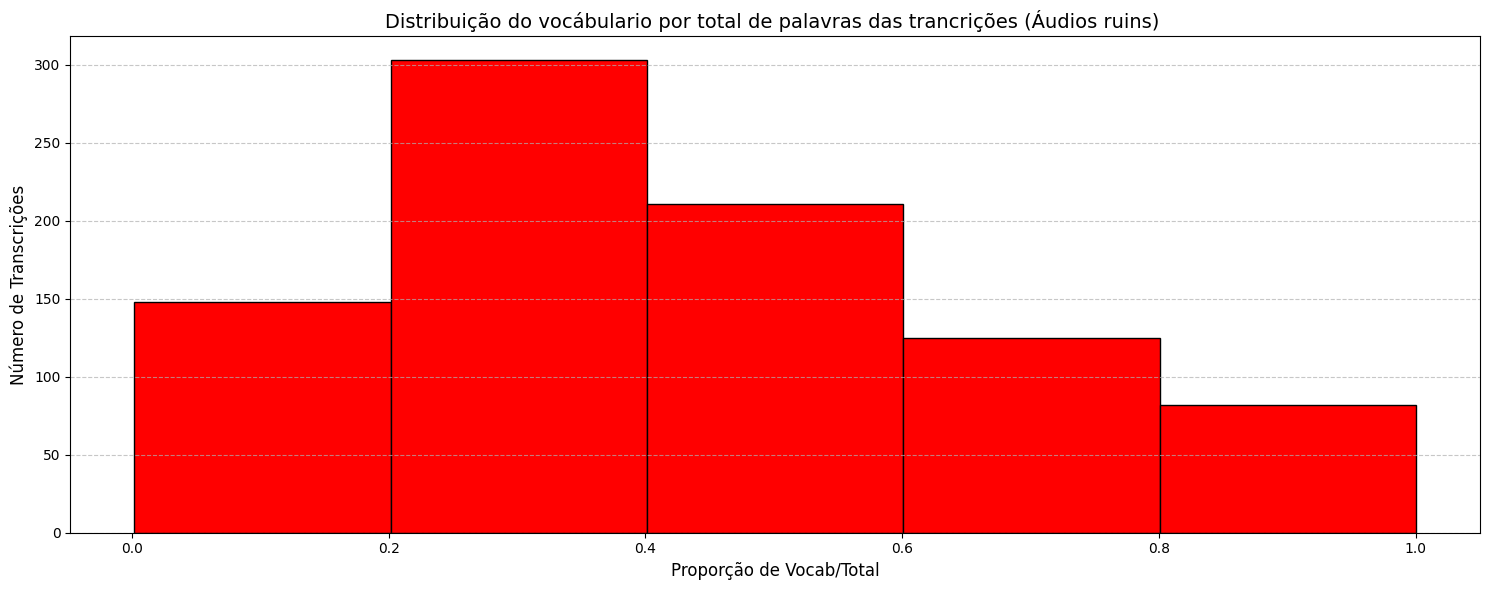

In [21]:
plt.figure(figsize=(15, 6))
n, bins_edges, patches = plt.hist(df_vocab_sil['Unique_Word_count/Word_count'], bins=5, color='red', edgecolor='black')

plt.xlabel('Proporção de Vocab/Total', fontsize=12)
plt.ylabel('Número de Transcrições', fontsize=12)
plt.title('Distribuição do vocábulario por total de palavras das trancrições (Áudios ruins) ', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
df_combinado = pd.merge(df_audios_sil_temp, df_vocab_sil, on='id', how='inner')
display(df_combinado)

,id,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,duracao_categoria,silencio/tempo,text,Word_count,Unique_Word_count,Unique_Word_count/Word_count
0,hEPS5wpurkM,66.850249,44100,0.104044,0.962973,0.108045,136.467381,0.061401,0,>60s,0.000000,verschiedencia de siowan comenrive possXiang,5,5,1.000000
1,XXBh0Fydirk,634.775521,48000,0.058259,1.093412,0.053282,21.353328,0.058474,25,>60s,0.039384,"a nova onda do momento, a nova febre do moment...",2055,599,0.291484
2,3IloQUdQ6T8,613.343500,48000,0.087393,1.104916,0.079095,23.552988,0.036577,15,>60s,0.024456,"seu galera, a gamer hagi nari e treinando mais...",1941,454,0.233900
3,t0OEDe-h7Ew,866.127542,48000,0.066992,1.013549,0.066096,27.605300,0.062524,1,>60s,0.001155,vamos ver se ele continua aqui na distribuicao...,1801,532,0.295391
4,RTekEjC4Nps,22.101333,48000,0.225782,1.193549,0.189169,31.268148,0.056754,0,10-25s,0.000000,ela espera o ano inteiro pra chegar o sa joao ...,58,35,0.603448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,bDGBT2VKXx0,135.808000,48000,0.014452,0.229142,0.063070,23.983972,0.043809,0,>60s,0.000000,"oi gente, tudo bem? sula aqui, gente, olha so,...",470,190,0.404255
886,Gvxm13mK5u8,69.450896,48000,0.073567,0.980765,0.075010,36.162817,0.034724,1,>60s,0.014399,40 se ele pudesse pegar do de 100 hoje ele peg...,296,102,0.344595
887,dX4rqi4_iss,14.464000,48000,0.188685,1.164248,0.162066,60.525055,0.076055,0,10-25s,0.000000,fiatinha! fiatinha! quero ver voce fazendo a d...,10,9,0.900000
888,kN3p6HIfW3Y,75.209438,48000,0.137584,1.105482,0.124456,66.339850,0.043569,0,>60s,0.000000,e ai e ai mesmo mais e ai motorista e ai e ai,13,5,0.384615


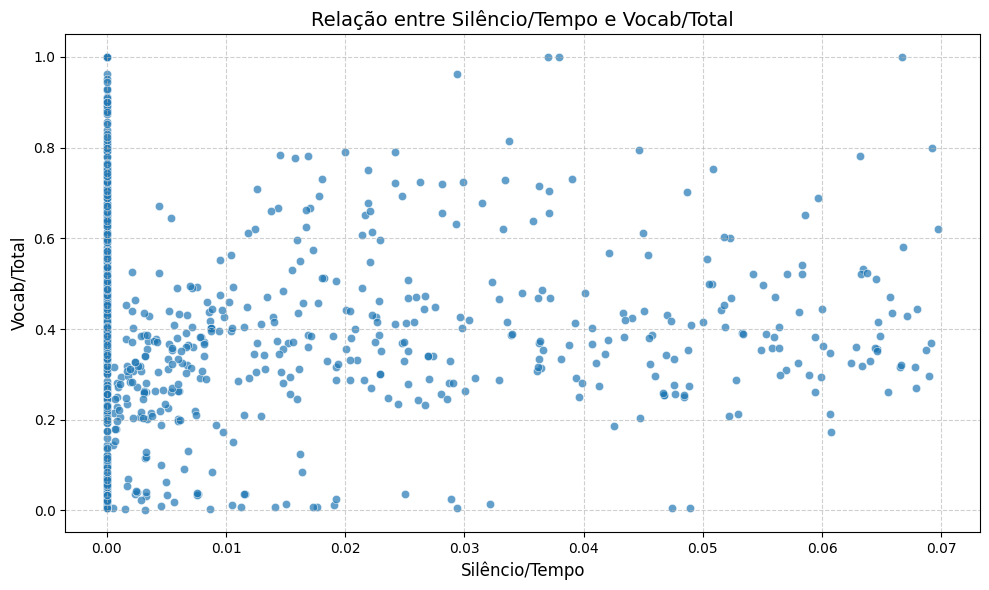


Correlação entre as duas variáveis:
                              silencio/tempo  Unique_Word_count/Word_count
silencio/tempo                      1.000000                     -0.040027
Unique_Word_count/Word_count       -0.040027                      1.000000


In [23]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_combinado, x='silencio/tempo', y='Unique_Word_count/Word_count', alpha=0.7)

# Adicionar rótulos e título
plt.title('Relação entre Silêncio/Tempo e Vocab/Total', fontsize=14)
plt.xlabel('Silêncio/Tempo', fontsize=12)
plt.ylabel('Vocab/Total', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Opcional: Se quiser ver a correlação numérica
print("\nCorrelação entre as duas variáveis:")
print(df_combinado[['silencio/tempo', 'Unique_Word_count/Word_count']].corr())

In [24]:
textos_curtos = df[df["Word_count"] <= 30]
display(textos_curtos)

ids_textos_curtos = textos_curtos["id"]
ids_audios_ruins = df_audios_ruins["id"]
count = ids_textos_curtos.isin(ids_audios_ruins).sum()
print(f"Número de transcrições que estão em áudios ruins e tem menos de 30 palavras: {count}")

,id,text,Word_count,Unique_Word_count,Unique_Word_count/Word_count
8,oUYku2T9pDQ,"muito bom, yuggaji! dizem queunaiuda!sim... vo...",26,25,0.961538
46,P1BVe9H3-yk,gef fdp,2,2,1.000000
51,SKzCWxjxqk4,,0,0,NaN
59,moee64Anbx4,,0,0,NaN
73,tMXTbckeQ-0,musica,1,1,1.000000
...,...,...,...,...,...
1918,Akq1cWX0TTM,aquilo hats lemon ailuhaeao,4,4,1.000000
1922,TbDBO90jPB4,meu deus!,2,2,1.000000
1946,87TiG34qexc,fim de lag,3,3,1.000000
1953,80r3-jnvywA,"eu sou eu, sou eu eu via no radio de pilha um ...",24,21,0.875000


Número de transcrições que estão em áudios ruins e tem menos de 30 palavras: 150


In [37]:
AUDIO_INFOS = "../filtrated_data_log/audio_infos2.csv"

df_audios = pd.read_csv(AUDIO_INFOS)
df_audios['arquivo'] = [arquivo.replace('.mp3','') for arquivo in df_audios['arquivo']]
df_audios.rename(columns={'arquivo': 'id'}, inplace=True)

filtro_ids = df['id'].isin(df_audios['id'])
df_aux = df[filtro_ids].copy()
df_combinado = pd.merge(df_audios, df_aux, on='id', how='inner')
display(df_combinado)


,Unnamed: 0,id,duracao_segundos,frequencia_amostragem,amplitude_media,amplitude_maxima,amplitude_ratio (mean/max),snr_estimado_db,zero_crossing_rate,regioes_silencio,duracao_categoria,silencio/tempo,text,Word_count,Unique_Word_count,Unique_Word_count/Word_count
0,0,myPV9PdsX04,348.786958,48000,0.026415,1.042867,0.025329,28.842549,0.039911,47,>60s,0.134753,"ola rapaziada, beleza? galera, e o seguinte, n...",456,201,0.440789
1,1,q_SI-rVN6iw,410.110854,48000,0.029762,0.927915,0.032074,35.811853,0.034090,92,>60s,0.224330,fala galera beleza rapaziada beleza quem fala ...,912,282,0.309211
2,2,0Pg4eX2Fo6g,388.928000,48000,0.040820,0.706327,0.057792,28.362591,0.032910,176,>60s,0.452526,demember fitness a configurar o ne aminoacido ...,408,206,0.504902
3,3,5plz1EPg10c,275.110042,48000,0.206517,1.280014,0.161340,43.374400,0.063981,77,>60s,0.279888,"continua, bora que bora, vou tentar girar aqui...",553,221,0.399638
4,4,P_iY5VFrozk,338.872021,48000,0.021286,0.947819,0.022458,29.139154,0.034929,73,>60s,0.215421,"fala rapaziada, beleza? galera, no video de ho...",572,258,0.451049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1932,1952,kN3p6HIfW3Y,75.209438,48000,0.137584,1.105482,0.124456,66.339850,0.043569,0,>60s,0.000000,e ai e ai mesmo mais e ai motorista e ai e ai,13,5,0.384615
1933,1953,zfKxM-uFgho,632.209708,48000,0.057196,0.989910,0.057779,26.054435,0.061720,3,>60s,0.004745,"eita pessoal, e disso que eu tava falando, olh...",1604,426,0.265586
1934,1954,Mo5ybNOwS80,456.980333,48000,0.033653,1.083810,0.031051,31.381006,0.040483,134,>60s,0.293229,"galera, estamos aqui no fortuna e tigue novame...",1442,445,0.308599
1935,1955,msLGDdIQUkw,165.442187,48000,0.026978,0.537679,0.050175,23.677936,0.047942,29,>60s,0.175288,"proxima materia, jogo do tigrinho, essa que fo...",355,183,0.515493


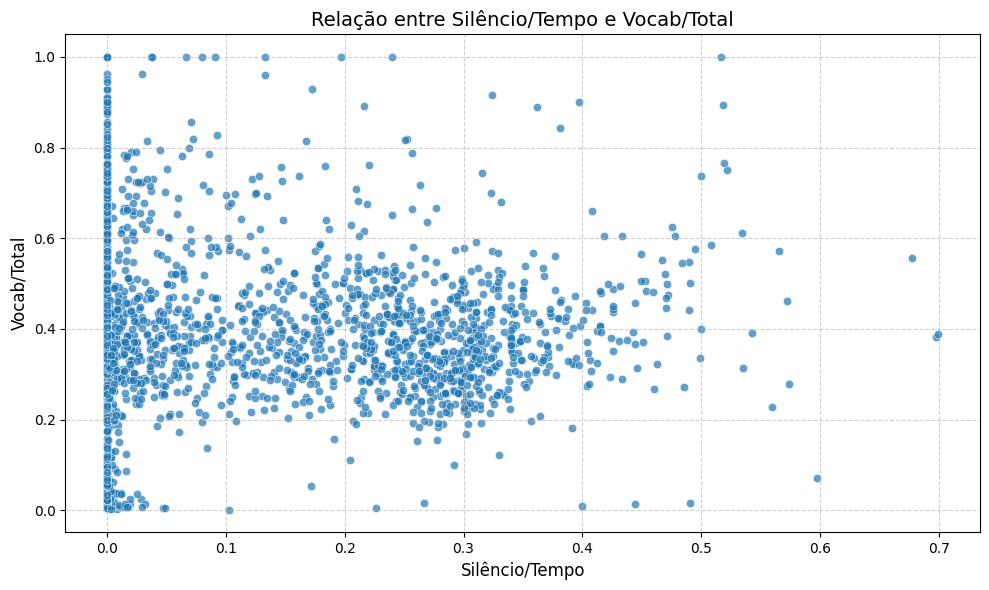


Correlação entre as duas variáveis:
                              silencio/tempo  Unique_Word_count/Word_count
silencio/tempo                      1.000000                     -0.078374
Unique_Word_count/Word_count       -0.078374                      1.000000


In [38]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_combinado, x='silencio/tempo', y='Unique_Word_count/Word_count', alpha=0.7)

# Adicionar rótulos e título
plt.title('Relação entre Silêncio/Tempo e Vocab/Total', fontsize=14)
plt.xlabel('Silêncio/Tempo', fontsize=12)
plt.ylabel('Vocab/Total', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Opcional: Se quiser ver a correlação numérica
print("\nCorrelação entre as duas variáveis:")
print(df_combinado[['silencio/tempo', 'Unique_Word_count/Word_count']].corr())